# Neutral-atom quantum computing for multi-hypothesis tracking

Run every cell from top to bottom. The notebook imports the preserved classical
screen, runs only a small neutral-atom subsample, and then creates the eight
publication figures.

The scientific grid uses baseline plus one combined-noise parameter. Object
count and random seed remain as design and replication variables. New quantum
work is capped at 25 minutes, while completed classical optimizations are
replayed directly from their stored selections and are never solved again.

In [1]:
# Imports: make the local src-layout package available before importing it.
from pathlib import Path
import sys

import matplotlib.pyplot as plt

project_root = Path.cwd().resolve()
source_root = project_root / "src"
if not (project_root / "pyproject.toml").is_file() or not source_root.is_dir():
    raise RuntimeError("Open user_notebook.ipynb from the repository root.")
if str(source_root) not in sys.path:
    sys.path.insert(0, str(source_root))

from neutral_atom_mht import (
    BENCHMARK_SCHEMA_VERSION,
    ClassicalSolver,
    HPC,
    HPCConfig,
    OvernightBenchmarkConfig,
    QUANTUM_DEMO_DATA_CONFIG,
    QuantumSolver,
    SyntheticDataGenerator,
    build_synthetic_scenarios,
    run_overnight_benchmark,
)
from cell_data import DATASET_NAME, load_tiff, raw_frame_path

## Reduced resumable benchmark

Only combined noise is varied as a degradation parameter; severity zero is the
shared baseline. The existing schema-2.1 classical screen supplies all exact
records, and the new schema-2.2 database accepts no old quantum records.
Checkpointed exact selections are fingerprint-validated and used to restore the
tracking trajectory without running the classical optimizer again.

Each new quantum result is committed to SQLite. The 25-minute forward-work
budget excludes inexpensive replay and CSV export, and an individual solver
call is allowed to finish atomically.

In [2]:
# Reduced combined-noise campaign: 120 scenarios, 4,800 reused exact frames.
BENCHMARK_AXIS = "combined"
BENCHMARK_SEVERITIES = (0.2, 0.4, 0.6, 0.8, 1.0)
BENCHMARK_OBJECT_COUNTS = (4, 12, 30, 55)
BENCHMARK_SEEDS = tuple(range(5))
BENCHMARK_FRAME_COUNT = 40
QUANTUM_QUOTA_PER_STRATUM = 3
BENCHMARK_FORWARD_WORK_MINUTES = 25.0

classical_checkpoint = (
    project_root
    / "outputs"
    / "overnight"
    / "schema-2.1"
    / "overnight"
    / "benchmark.sqlite3"
)
if not classical_checkpoint.is_file():
    raise FileNotFoundError(
        "The preserved schema-2.1 classical checkpoint is required: "
        f"{classical_checkpoint}"
    )

benchmark_scenarios = build_synthetic_scenarios(
    axes=("baseline", BENCHMARK_AXIS),
    severity_levels=BENCHMARK_SEVERITIES,
    object_counts=BENCHMARK_OBJECT_COUNTS,
    seeds=BENCHMARK_SEEDS,
    frame_count=BENCHMARK_FRAME_COUNT,
    image_shape=QUANTUM_DEMO_DATA_CONFIG.image_shape,
)
overnight_config = OvernightBenchmarkConfig(
    scenarios=benchmark_scenarios,
    output_directory=(
        project_root
        / "outputs"
        / "overnight"
        / f"schema-{BENCHMARK_SCHEMA_VERSION}"
        / "combined_quick"
    ),
    exact_checkpoint_source=classical_checkpoint,
    exact_maximum_component_nodes=128,
    run_quantum=True,
    quantum_max_nonclique_component_nodes=8,
    quantum_quota_per_stratum=QUANTUM_QUOTA_PER_STRATUM,
    store_detailed_records=False,
    forward_work_budget_seconds=BENCHMARK_FORWARD_WORK_MINUTES * 60.0,
    progress_every_frames=25,
    resume=True,
)
{
    "noise_parameter": BENCHMARK_AXIS,
    "scenarios": len(benchmark_scenarios),
    "reused_exact_frames": len(benchmark_scenarios) * BENCHMARK_FRAME_COUNT,
    "quantum_quota_per_severity_size_stratum": QUANTUM_QUOTA_PER_STRATUM,
    "forward_work_budget_minutes": BENCHMARK_FORWARD_WORK_MINUTES,
    "classical_checkpoint": str(classical_checkpoint),
    "output_directory": str(overnight_config.output_directory),
}

{'noise_parameter': 'combined',
 'scenarios': 120,
 'reused_exact_frames': 4800,
 'quantum_quota_per_severity_size_stratum': 3,
 'forward_work_budget_minutes': 25.0,
 'classical_checkpoint': 'C:\\Projects\\Summer School Challenge\\Neutral-Atom-QC-for-MHT\\outputs\\overnight\\schema-2.1\\overnight\\benchmark.sqlite3',
 'output_directory': 'C:\\Projects\\Summer School Challenge\\Neutral-Atom-QC-for-MHT\\outputs\\overnight\\schema-2.2\\combined_quick'}

In [3]:
# Run only missing quantum work; every completed attempt is durable.
overnight_result = run_overnight_benchmark(
    overnight_config, progress=lambda update: print(update, flush=True)
)
benchmark_records = list(overnight_result.records)
benchmark_summary = dict(overnight_result.summary)
benchmark_summary.update(
    {
        "database": str(overnight_result.database_path),
        "csv": str(overnight_result.csv_path),
        "stopped_reason": overnight_result.stopped_reason,
    }
)
benchmark_summary

{'phase': 'quantum', 'scenario': 'baseline__severity-000__objects-012__seed-001', 'frame': 25, 'completed': 25, 'total': 108}
{'phase': 'quantum', 'scenario': 'combined__severity-060__objects-004__seed-002', 'frame': 12, 'completed': 50, 'total': 108}
{'phase': 'quantum', 'scenario': 'combined__severity-080__objects-012__seed-003', 'frame': 2, 'completed': 75, 'total': 108}
{'phase': 'quantum', 'scenario': 'combined__severity-080__objects-004__seed-004', 'frame': 29, 'completed': 100, 'total': 108}


{'benchmark_schema_version': '2.2',
 'scenario_count': 120,
 'expected_exact_frames': 4800,
 'checkpointed_exact_frames': 4800,
 'imported_exact_frames': 4800,
 'exact_screen_finished': True,
 'exact_all_successful': True,
 'exact_complete': True,
 'exact_pending_frames': 0,
 'exact_blocked_frames': 0,
 'exact_successes': 4800,
 'exact_failures': 0,
 'quantum_candidates': 108,
 'quantum_candidate_strata': 36,
 'quantum_quota_per_stratum': 3,
 'quantum_complete': True,
 'quantum_pending_frames': 0,
 'quantum_attempts': 108,
 'quantum_successes': 67,
 'quantum_failures': 41,
 'mean_detection_recall': 0.4416568813131313,
 'mean_detection_precision': 0.6539139199025675,
 'tracking_evaluated_frames': 4800,
 'matched_track_gt_count': 49972,
 'identity_correct_match_count': 25329,
 'matched_track_gt_identity_correctness': 0.5068638437525014,
 'id_switch_count': 23491,
 'fragmentation_count': 19116,
 'tracking_recall': 0.4123102310231023,
 'tracking_precision': 0.4203106995365581,
 'elapsed_se

## Publication figures

The following cells save eight reproducible figures under outputs/figures.
Figures 1–3 show detections, the validated frame-2 conflict graph, and its
solver-produced neutral-atom layout. Figures 4–8 summarize the reduced
combined-noise campaign. Missing, oversized, or failed quantum runs remain
visible as coverage outcomes instead of being discarded.

In [4]:
# Shared publication-figure imports, output path, and rendering helpers.
from itertools import combinations
import json

import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Circle

from detection import detections_from_label_image
from graph import logical_layout

figure_output_dir = project_root / "outputs" / "figures"
figure_output_dir.mkdir(parents=True, exist_ok=True)

def finish_figure(figure, filename):
    path = figure_output_dir / filename
    figure.tight_layout()
    figure.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(figure)
    return path

def draw_detection_overlay(axis, image, detection, title):
    axis.imshow(image, cmap="gray")
    if np.any(detection.labels):
        axis.contour(
            detection.labels > 0, levels=[0.5],
            colors="#00D4FF", linewidths=0.7,
        )
    axis.scatter(
        [item.x_px for item in detection.detections],
        [item.y_px for item in detection.detections],
        s=42, facecolors="none", edgecolors="#FF4D4D", linewidths=1.2,
    )
    axis.set_title(f"{title} ({len(detection.detections)} detections)")
    axis.set_axis_off()

def finite_values(rows, key):
    values = []
    for row in rows:
        value = row.get(key)
        if value is not None and np.isfinite(float(value)):
            values.append(float(value))
    return np.asarray(values, dtype=float)

def matching_rows(rows, axis_name, severity):
    return [
        row for row in rows
        if row["axis"] == axis_name and np.isclose(row["severity"], severity)
    ]

def draw_heatmap(
    axis, matrix, row_labels, column_labels, *,
    title, colorbar_label, cmap="viridis", vmin=None, vmax=None,
    value_format=".2f", annotations=None,
):
    image = axis.imshow(matrix, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    axis.set_xticks(range(len(column_labels)), column_labels)
    axis.set_yticks(range(len(row_labels)), row_labels)
    axis.set_xlabel("combined-noise severity")
    axis.set_title(title)
    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            value = matrix[row_index, column_index]
            label = format(value, value_format) if np.isfinite(value) else "—"
            if annotations is not None and annotations[row_index, column_index]:
                label += f"\n{annotations[row_index, column_index]}"
            rgba = (
                image.cmap(image.norm(value))
                if np.isfinite(value) else (1, 1, 1, 1)
            )
            luminance = (
                0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
            )
            axis.text(
                column_index, row_index, label,
                ha="center", va="center", fontsize=8,
                color="white" if luminance < 0.48 else "black",
            )
    axis.figure.colorbar(image, ax=axis, label=colorbar_label)
    return image

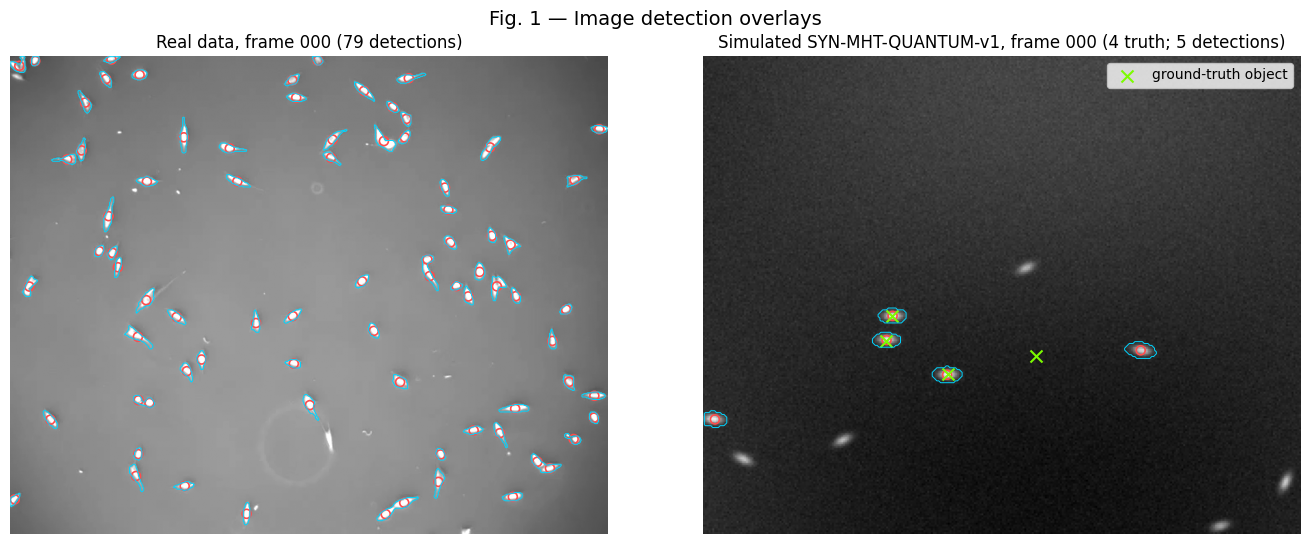

{'path': WindowsPath('C:/Projects/Summer School Challenge/Neutral-Atom-QC-for-MHT/outputs/figures/fig1_detection_overlays.png'),
 'real_data_available': True,
 'synthetic_ground_truth': 4,
 'synthetic_detections': 5}

In [5]:
# Fig. 1 — Real and simulated detection overlays.
synthetic_image, synthetic_labels = next(
    SyntheticDataGenerator(QUANTUM_DEMO_DATA_CONFIG).iter_frames()
)
figure_hpc_config = HPCConfig()
synthetic_detection = HPC(
    figure_hpc_config, sequence=QUANTUM_DEMO_DATA_CONFIG.sequence
).observe(synthetic_image, frame=0).detection
synthetic_truth = detections_from_label_image(
    synthetic_labels,
    sequence=QUANTUM_DEMO_DATA_CONFIG.sequence,
    frame=0,
    source="synthetic_ground_truth",
)

figure, axes = plt.subplots(1, 2, figsize=(14, 5.5))
real_dataset_root = project_root / "data" / DATASET_NAME
real_path = raw_frame_path(real_dataset_root, 0)
if real_path.is_file():
    real_image = load_tiff(real_path)
    real_detection = HPC(
        figure_hpc_config, sequence="01"
    ).observe(real_image, frame=0).detection
    draw_detection_overlay(
        axes[0], real_image, real_detection, "Real data, frame 000"
    )
else:
    axes[0].set_facecolor("#F3F4F6")
    axes[0].text(
        0.5, 0.56, "Real sequence not installed",
        ha="center", va="center", fontsize=13,
    )
    axes[0].text(
        0.5, 0.44, str(real_path),
        ha="center", va="center", fontsize=8, color="#666666", wrap=True,
    )
    axes[0].set_title("Real data, frame 000")
    axes[0].set_xticks([])
    axes[0].set_yticks([])
draw_detection_overlay(
    axes[1], synthetic_image, synthetic_detection,
    f"Simulated {QUANTUM_DEMO_DATA_CONFIG.dataset_name}, frame 000",
)
axes[1].scatter(
    [item.x_px for item in synthetic_truth],
    [item.y_px for item in synthetic_truth],
    s=75, marker="x", color="#7CFC00", linewidths=1.5,
    label="ground-truth object",
)
axes[1].set_title(
    f"Simulated {QUANTUM_DEMO_DATA_CONFIG.dataset_name}, frame 000 "
    f"({len(synthetic_truth)} truth; "
    f"{len(synthetic_detection.detections)} detections)"
)
axes[1].legend(loc="upper right")
figure.suptitle("Fig. 1 — Image detection overlays", fontsize=14)
fig1_path = finish_figure(figure, "fig1_detection_overlays.png")
{
    "path": fig1_path,
    "real_data_available": real_path.is_file(),
    "synthetic_ground_truth": len(synthetic_truth),
    "synthetic_detections": len(synthetic_detection.detections),
}

In [6]:
# Reproduce the validated frame-2 example used only by Figs. 2 and 3.
# The large campaign above supplies every aggregate performance figure.
example_reference = HPC(HPCConfig(), sequence=QUANTUM_DEMO_DATA_CONFIG.sequence)
example_exact_solver = ClassicalSolver(maximum_component_nodes=8)
example_quantum_solver = QuantumSolver(maximum_component_nodes=8)
example_prepared = None
example_execution = None
example_exact_result = None
for example_frame, (example_image, _) in enumerate(
    SyntheticDataGenerator(QUANTUM_DEMO_DATA_CONFIG).iter_frames()
):
    prepared_frame = example_reference.prepare_frame(
        example_image, frame=example_frame
    )
    exact_result = example_exact_solver.solve(prepared_frame.solver_input())
    if not exact_result.successful:
        raise RuntimeError(f"Validated exact example failed at frame {example_frame}")
    if example_frame == 2:
        example_prepared = prepared_frame
        example_exact_result = exact_result
        example_execution = example_quantum_solver.execute(
            prepared_frame.solver_input()
        )
    example_reference.advance(prepared_frame, exact_result)
    if example_frame == 2:
        break

if example_prepared is None or example_execution is None or not example_execution.successful:
    raise RuntimeError("The validated frame-2 quantum example was not produced")
simulated_example_runs = tuple(
    run for run in example_execution.runs if run.program is not None
)
if not simulated_example_runs:
    raise RuntimeError(
        "Frame 2 contains no simulated component; regenerate the validated preset"
    )
example_run = max(
    simulated_example_runs,
    key=lambda run: (len(run.node_ids), -run.component_id),
)
{
    "frame": example_prepared.frame,
    "graph_nodes": len(example_prepared.graph.nodes),
    "quantum_status": example_execution.status,
    "selection_agrees": (
        example_execution.selected_ids == example_exact_result.selected_ids
    ),
}

{'frame': 2,
 'graph_nodes': 7,
 'quantum_status': 'completed',
 'selection_agrees': True}

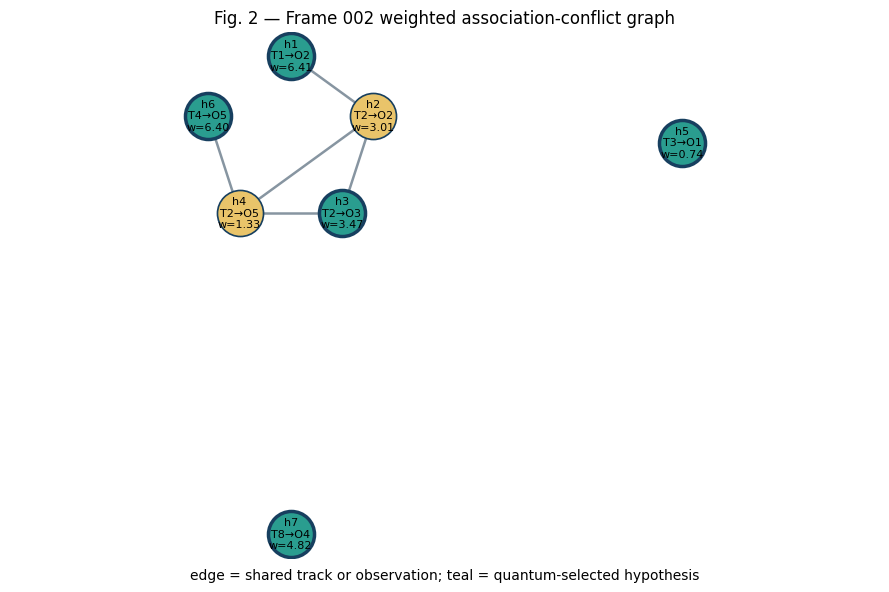

WindowsPath('C:/Projects/Summer School Challenge/Neutral-Atom-QC-for-MHT/outputs/figures/fig2_conflict_graph.png')

In [7]:
# Fig. 2 — Logical embedding of the frame-2 weighted conflict graph.
example_graph = example_prepared.graph
graph_positions = logical_layout(example_graph)
quantum_selected = set(example_execution.selected_ids)
figure, axis = plt.subplots(figsize=(9, 6))
for left, right in example_graph.edges:
    axis.plot(
        [graph_positions[left][0], graph_positions[right][0]],
        [graph_positions[left][1], graph_positions[right][1]],
        color="#8795A1", linewidth=1.8, zorder=1,
    )
for node in example_graph.nodes:
    x_value, y_value = graph_positions[node.node_id]
    selected = node.node_id in quantum_selected
    axis.scatter(
        [x_value], [y_value], s=1100,
        color="#2A9D8F" if selected else "#E9C46A",
        edgecolor="#173F5F", linewidth=2.5 if selected else 1.2, zorder=2,
    )
    axis.text(
        x_value, y_value,
        f"h{node.node_id}\nT{node.track_id}→O{node.observation_id}\nw={node.weight:.2f}",
        ha="center", va="center", fontsize=8, zorder=3,
    )
axis.set_title("Fig. 2 — Frame 002 weighted association-conflict graph")
axis.text(0.5, -0.04, "edge = shared track or observation; teal = quantum-selected hypothesis", transform=axis.transAxes, ha="center")
axis.set_aspect("equal", adjustable="datalim")
axis.axis("off")
fig2_path = finish_figure(figure, "fig2_conflict_graph.png")
fig2_path

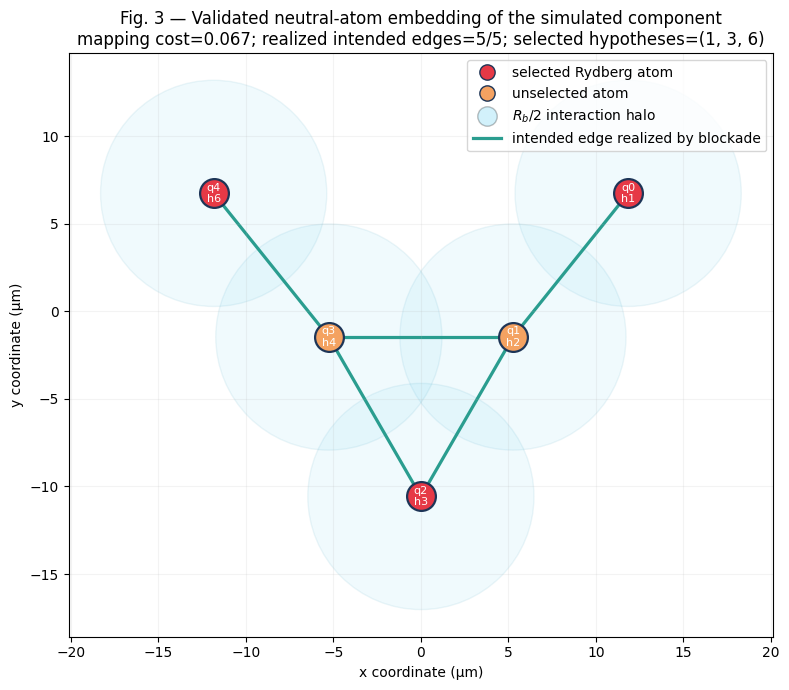

WindowsPath('C:/Projects/Summer School Challenge/Neutral-Atom-QC-for-MHT/outputs/figures/fig3_neutral_atom_embedding.png')

In [8]:
# Fig. 3 — Validated physical neutral-atom layout produced by the solver.
program = example_run.program
if program is None:
    raise RuntimeError("The selected example has no neutral-atom program")
component = program.component
coordinates = dict(zip(example_run.node_ids, example_run.coordinates, strict=True))
qubit_by_node = dict(zip(component.node_ids, component.qubit_ids, strict=True))
blockade_distance = program.sequence.device.rydberg_blockade_radius(program.omega)
selected_atoms = set(example_run.selected_ids)
intended_edges = {tuple(sorted(edge)) for edge in component.edges}
physical_edges = set()
for left, right in combinations(component.node_ids, 2):
    separation = np.linalg.norm(
        np.asarray(coordinates[left]) - np.asarray(coordinates[right])
    )
    if separation <= blockade_distance:
        physical_edges.add(tuple(sorted((left, right))))
if physical_edges != intended_edges:
    raise RuntimeError(
        "The corrected Fig. 3 layout does not exactly realize the logical graph"
    )

figure, axis = plt.subplots(figsize=(8, 7))
for node_id, (x_value, y_value) in coordinates.items():
    axis.add_patch(Circle(
        (x_value, y_value), blockade_distance / 2.0,
        facecolor="#4CC9F0", edgecolor="#168AAD", alpha=0.08, linewidth=1.0,
    ))
for left, right in sorted(intended_edges | physical_edges):
    if (left, right) in intended_edges and (left, right) in physical_edges:
        color, linestyle, linewidth = "#2A9D8F", "-", 2.3
    elif (left, right) in intended_edges:
        color, linestyle, linewidth = "#D62828", "--", 2.0
    else:
        color, linestyle, linewidth = "#7B2CBF", ":", 2.0
    axis.plot(
        [coordinates[left][0], coordinates[right][0]],
        [coordinates[left][1], coordinates[right][1]],
        color=color, linestyle=linestyle, linewidth=linewidth, zorder=1,
    )
for node_id in component.node_ids:
    x_value, y_value = coordinates[node_id]
    selected = node_id in selected_atoms
    axis.scatter(
        [x_value], [y_value], s=430,
        color="#E63946" if selected else "#F4A261",
        edgecolor="#1D3557", linewidth=1.6, zorder=3,
    )
    axis.text(
        x_value, y_value, f"{qubit_by_node[node_id]}\nh{node_id}",
        ha="center", va="center", fontsize=8, color="white", zorder=4,
    )
legend_handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#E63946", markeredgecolor="#1D3557", markersize=11, label="selected Rydberg atom"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#F4A261", markeredgecolor="#1D3557", markersize=11, label="unselected atom"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#4CC9F0", alpha=0.25, markersize=14, label="$R_b/2$ interaction halo"),
]
if intended_edges & physical_edges:
    legend_handles.append(Line2D([0], [0], color="#2A9D8F", linewidth=2.3, label="intended edge realized by blockade"))
if intended_edges - physical_edges:
    legend_handles.append(Line2D([0], [0], color="#D62828", linestyle="--", linewidth=2.0, label="intended edge outside blockade"))
if physical_edges - intended_edges:
    legend_handles.append(Line2D([0], [0], color="#7B2CBF", linestyle=":", linewidth=2.0, label="unintended blockade pair"))
axis.legend(handles=legend_handles, loc="upper right")
realized_count = len(intended_edges & physical_edges)
axis.set(
    xlabel="x coordinate (μm)", ylabel="y coordinate (μm)",
    title=("Fig. 3 — Validated neutral-atom embedding of the simulated component\n"
           f"mapping cost={example_run.mapping_cost:.3f}; realized intended edges="
           f"{realized_count}/{len(intended_edges)}; "
           f"selected hypotheses={example_run.selected_ids}"),
)
axis.set_aspect("equal", adjustable="datalim")
axis.grid(alpha=0.15)
fig3_path = finish_figure(figure, "fig3_neutral_atom_embedding.png")
fig3_path

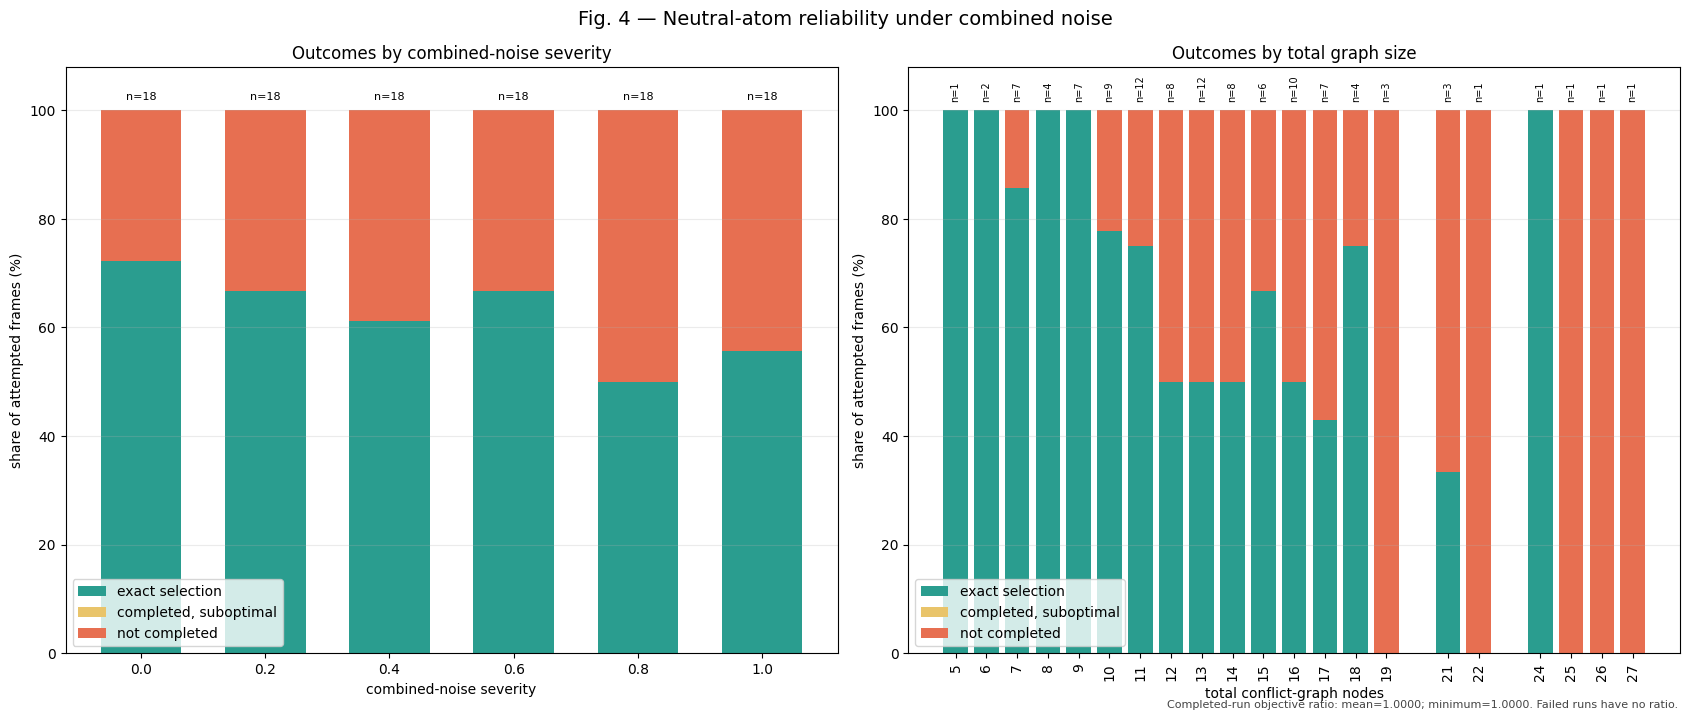

WindowsPath('C:/Projects/Summer School Challenge/Neutral-Atom-QC-for-MHT/outputs/figures/fig4_quantum_reliability.png')

In [9]:
# Fig. 4 — Quantum completion and objective outcomes under combined noise.
plot_severities = (0.0, *BENCHMARK_SEVERITIES)
prepared_benchmark_rows = [
    row for row in benchmark_records if row.get("input_fingerprint") is not None
]
attempted_quantum_rows = [
    row for row in benchmark_records if bool(row.get("quantum_attempted"))
]
successful_quantum_rows = [
    row for row in attempted_quantum_rows
    if row.get("quantum_status") == "completed"
    and row.get("relative_objective") is not None
]

severity_exact_percentages = []
severity_suboptimal_percentages = []
severity_failure_percentages = []
severity_attempt_counts = []
for severity in plot_severities:
    source_axis = "baseline" if np.isclose(severity, 0.0) else BENCHMARK_AXIS
    attempts = matching_rows(attempted_quantum_rows, source_axis, severity)
    completed = [
        row for row in attempts if row.get("quantum_status") == "completed"
    ]
    exact_count = sum(row.get("selection_agrees") is True for row in completed)
    suboptimal_count = len(completed) - exact_count
    failure_count = len(attempts) - len(completed)
    total = len(attempts)
    severity_attempt_counts.append(total)
    severity_exact_percentages.append(
        100.0 * exact_count / total if total else np.nan
    )
    severity_suboptimal_percentages.append(
        100.0 * suboptimal_count / total if total else np.nan
    )
    severity_failure_percentages.append(
        100.0 * failure_count / total if total else np.nan
    )

figure, (coverage_axis, size_axis) = plt.subplots(1, 2, figsize=(17, 7.2))
coverage_axis.bar(
    plot_severities, severity_exact_percentages, width=0.13,
    color="#2A9D8F", label="exact selection",
)
coverage_axis.bar(
    plot_severities, severity_suboptimal_percentages, width=0.13,
    bottom=severity_exact_percentages,
    color="#E9C46A", label="completed, suboptimal",
)
severity_failure_bottom = (
    np.asarray(severity_exact_percentages)
    + np.asarray(severity_suboptimal_percentages)
)
coverage_axis.bar(
    plot_severities, severity_failure_percentages, width=0.13,
    bottom=severity_failure_bottom,
    color="#E76F51", label="not completed",
)
for severity, total in zip(
    plot_severities, severity_attempt_counts, strict=True
):
    coverage_axis.text(
        severity, 101.5, f"n={total}",
        ha="center", va="bottom", fontsize=8,
    )
coverage_axis.set(
    xlabel="combined-noise severity",
    ylabel="share of attempted frames (%)",
    ylim=(0, 108),
    title="Outcomes by combined-noise severity",
)
coverage_axis.set_xticks(plot_severities)
coverage_axis.grid(axis="y", alpha=0.25)
coverage_axis.legend(loc="lower left")

total_graph_nodes = sorted({
    int(row["graph_nodes"]) for row in attempted_quantum_rows
})
exact_percentages, suboptimal_percentages, failure_percentages = [], [], []
size_attempt_counts = []
for node_count in total_graph_nodes:
    attempts = [
        row for row in attempted_quantum_rows
        if int(row["graph_nodes"]) == node_count
    ]
    completed = [
        row for row in attempts if row.get("quantum_status") == "completed"
    ]
    exact_count = sum(row.get("selection_agrees") is True for row in completed)
    suboptimal_count = len(completed) - exact_count
    failure_count = len(attempts) - len(completed)
    total = len(attempts)
    size_attempt_counts.append(total)
    exact_percentages.append(100.0 * exact_count / total)
    suboptimal_percentages.append(100.0 * suboptimal_count / total)
    failure_percentages.append(100.0 * failure_count / total)
size_axis.bar(
    total_graph_nodes, exact_percentages,
    color="#2A9D8F", label="exact selection",
)
size_axis.bar(
    total_graph_nodes, suboptimal_percentages, bottom=exact_percentages,
    color="#E9C46A", label="completed, suboptimal",
)
failure_bottom = np.asarray(exact_percentages) + np.asarray(suboptimal_percentages)
size_axis.bar(
    total_graph_nodes, failure_percentages, bottom=failure_bottom,
    color="#E76F51", label="not completed",
)
for node_count, total in zip(
    total_graph_nodes, size_attempt_counts, strict=True
):
    size_axis.text(
        node_count, 101.5, f"n={total}",
        ha="center", va="bottom", fontsize=7, rotation=90,
    )
size_axis.set(
    xlabel="total conflict-graph nodes",
    ylabel="share of attempted frames (%)",
    ylim=(0, 108),
    title="Outcomes by total graph size",
)
size_axis.set_xticks(total_graph_nodes)
size_axis.tick_params(axis="x", labelrotation=90)
size_axis.grid(axis="y", alpha=0.25)
size_axis.legend(loc="lower left")
finite_ratios = finite_values(successful_quantum_rows, "relative_objective")
ratio_summary = (
    f"Completed-run objective ratio: mean={np.mean(finite_ratios):.4f}; "
    f"minimum={np.min(finite_ratios):.4f}. Failed runs have no ratio."
    if finite_ratios.size else "No completed quantum objective ratios."
)
figure.suptitle(
    "Fig. 4 — Neutral-atom reliability under combined noise", fontsize=14
)
figure.text(
    0.99, 0.01, ratio_summary,
    ha="right", fontsize=8, color="#444444",
)
fig4_path = finish_figure(figure, "fig4_quantum_reliability.png")
fig4_path

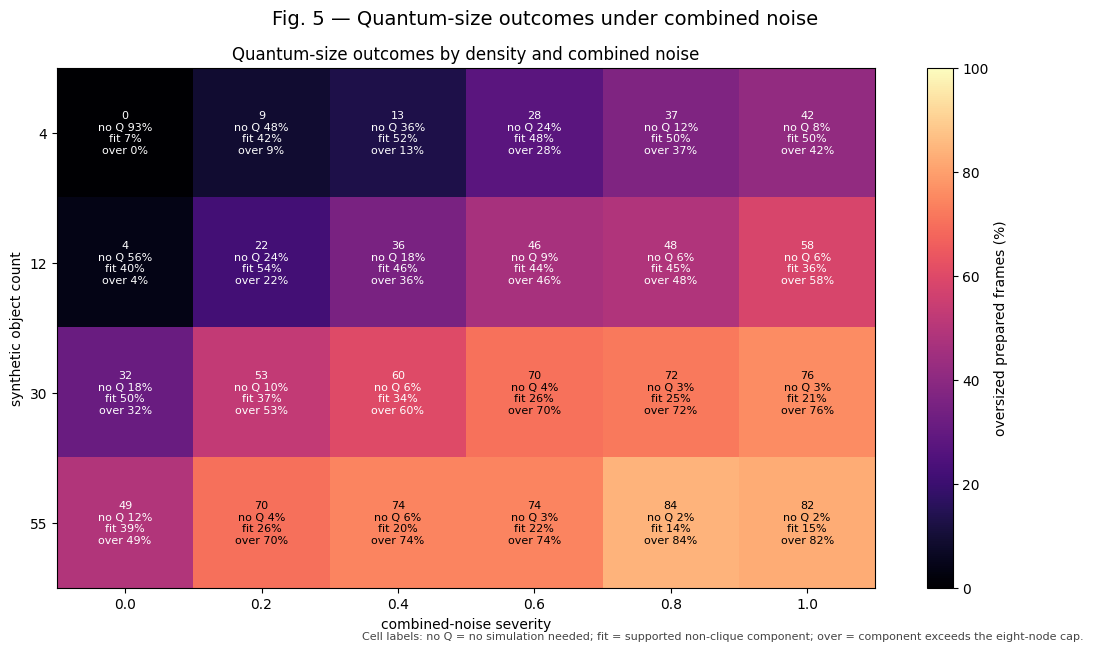

WindowsPath('C:/Projects/Summer School Challenge/Neutral-Atom-QC-for-MHT/outputs/figures/fig5_quantum_size_outcomes.png')

In [10]:
# Fig. 5 — No-work, supported, and oversized frames under combined noise.
oversized_matrix = np.full(
    (len(BENCHMARK_OBJECT_COUNTS), len(plot_severities)), np.nan
)
outcome_annotations = np.full(oversized_matrix.shape, "", dtype=object)
for object_index, object_count in enumerate(BENCHMARK_OBJECT_COUNTS):
    for severity_index, severity in enumerate(plot_severities):
        source_axis = "baseline" if np.isclose(severity, 0.0) else BENCHMARK_AXIS
        rows = [
            row for row in prepared_benchmark_rows
            if row["axis"] == source_axis
            and row["object_count"] == object_count
            and np.isclose(row["severity"], severity)
        ]
        if not rows:
            continue
        sizes = [
            int(row["maximum_nonclique_component_nodes"]) for row in rows
        ]
        no_work = sum(size == 0 for size in sizes)
        supported = sum(
            1 <= size <= overnight_config.quantum_max_nonclique_component_nodes
            for size in sizes
        )
        oversized = len(rows) - no_work - supported
        oversized_matrix[object_index, severity_index] = (
            100.0 * oversized / len(rows)
        )
        outcome_annotations[object_index, severity_index] = (
            f"no Q {100.0 * no_work / len(rows):.0f}%\n"
            f"fit {100.0 * supported / len(rows):.0f}%\n"
            f"over {100.0 * oversized / len(rows):.0f}%"
        )

figure, outcome_axis = plt.subplots(figsize=(11, 6.5))
draw_heatmap(
    outcome_axis,
    oversized_matrix,
    BENCHMARK_OBJECT_COUNTS,
    plot_severities,
    title="Quantum-size outcomes by density and combined noise",
    colorbar_label="oversized prepared frames (%)",
    cmap="magma",
    vmin=0.0,
    vmax=100.0,
    value_format=".0f",
    annotations=outcome_annotations,
)
outcome_axis.set_ylabel("synthetic object count")
figure.suptitle(
    "Fig. 5 — Quantum-size outcomes under combined noise", fontsize=14
)
figure.text(
    0.99, 0.01,
    "Cell labels: no Q = no simulation needed; fit = supported non-clique "
    "component; over = component exceeds the eight-node cap.",
    ha="right", fontsize=8, color="#444444",
)
fig5_path = finish_figure(figure, "fig5_quantum_size_outcomes.png")
fig5_path

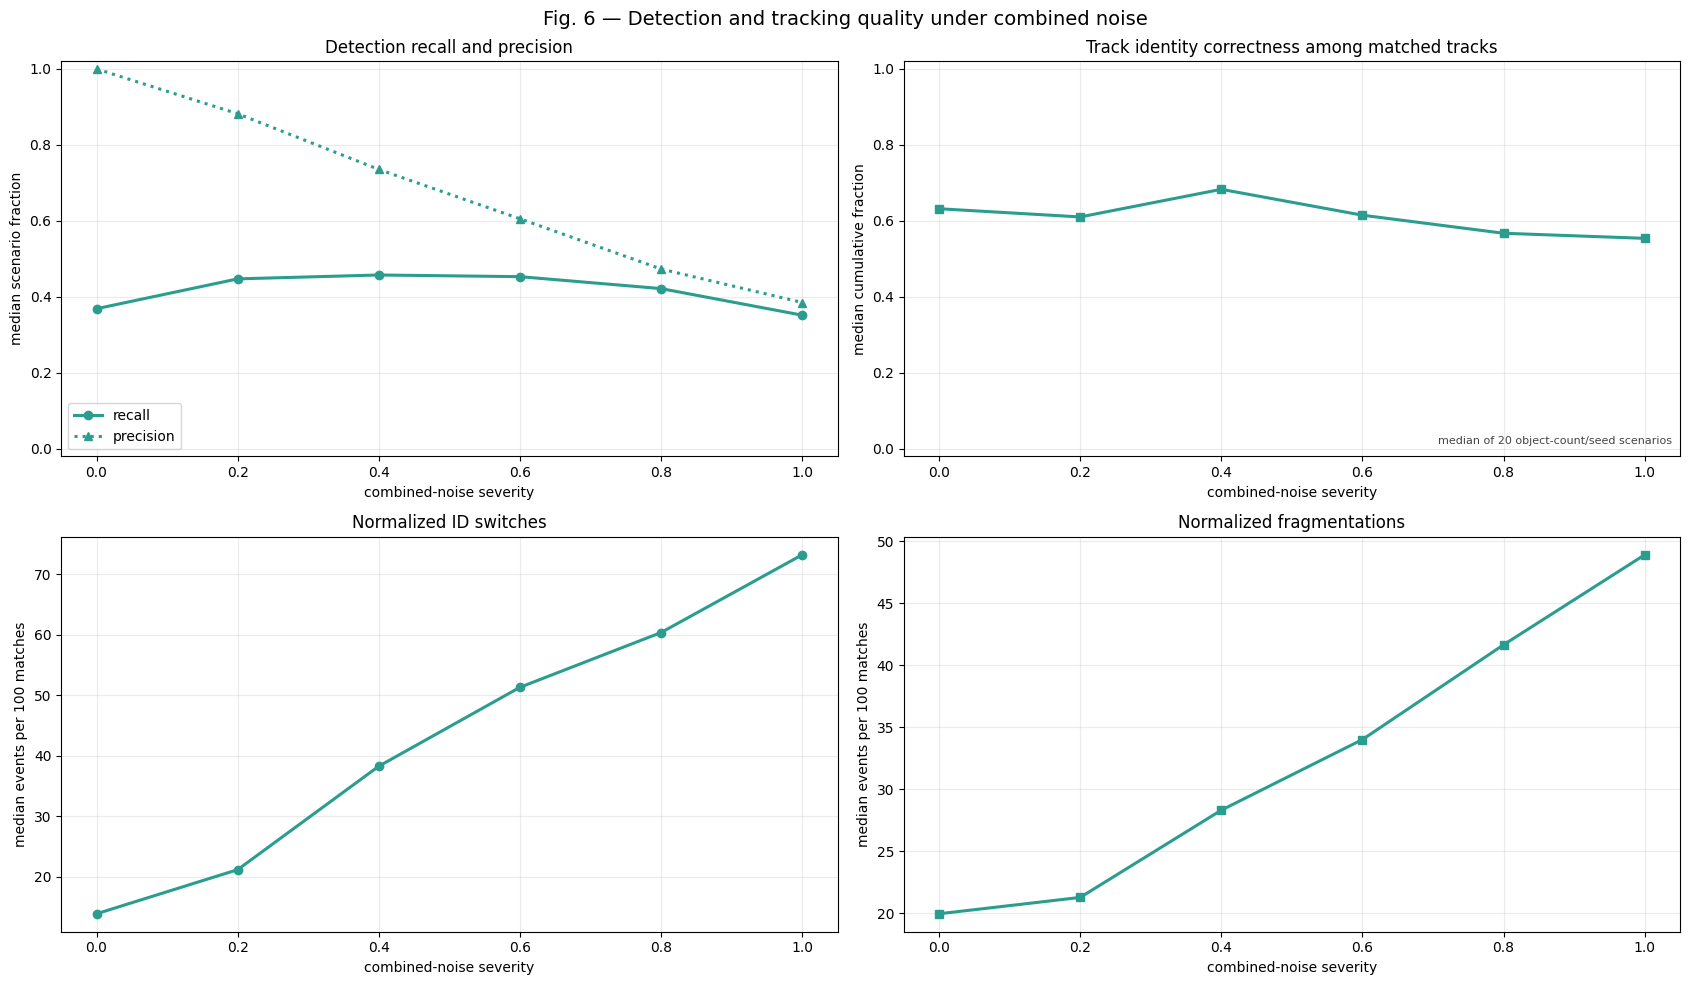

WindowsPath('C:/Projects/Summer School Challenge/Neutral-Atom-QC-for-MHT/outputs/figures/fig6_detection_and_tracking_quality.png')

In [11]:
# Fig. 6 — Scenario-level detection and tracking outcomes under combined noise.
tracking_rows = [
    row for row in benchmark_records
    if row.get("tracking_metrics_status") == "completed"
]
rows_by_scenario = {}
for row in tracking_rows:
    rows_by_scenario.setdefault(row["scenario"], []).append(row)
scenario_quality_rows = []
for scenario_name, rows in rows_by_scenario.items():
    rows = sorted(rows, key=lambda row: row["frame"])
    latest = rows[-1]
    matched_detections = sum(
        int(row["matched_detection_count"]) for row in rows
    )
    truth_instances = sum(int(row["ground_truth_count"]) for row in rows)
    detection_instances = sum(int(row["detection_count"]) for row in rows)
    matched_tracks = int(latest["cumulative_matched_track_gt_count"])
    correct_tracks = int(latest["cumulative_identity_correct_match_count"])
    scenario_quality_rows.append({
        "scenario": scenario_name,
        "axis": latest["axis"],
        "severity": latest["severity"],
        "object_count": latest["object_count"],
        "detection_recall": (
            matched_detections / truth_instances if truth_instances else 1.0
        ),
        "detection_precision": (
            matched_detections / detection_instances
            if detection_instances else 0.0
        ),
        "identity_correctness": (
            correct_tracks / matched_tracks if matched_tracks else np.nan
        ),
        "id_switches_per_100_matches": (
            100.0 * int(latest["cumulative_id_switch_count"]) / matched_tracks
            if matched_tracks else np.nan
        ),
        "fragmentations_per_100_matches": (
            100.0 * int(latest["cumulative_fragmentation_count"]) / matched_tracks
            if matched_tracks else np.nan
        ),
    })

def condition_medians(metric_key):
    medians = []
    for severity in plot_severities:
        source_axis = "baseline" if np.isclose(severity, 0.0) else BENCHMARK_AXIS
        rows = [
            row for row in scenario_quality_rows
            if row["axis"] == source_axis
            and np.isclose(row["severity"], severity)
        ]
        values = finite_values(rows, metric_key)
        medians.append(np.median(values) if values.size else np.nan)
    return medians

combined_color = "#2A9D8F"
figure, quality_axes = plt.subplots(2, 2, figsize=(17, 10))
detection_axis, identity_axis, switch_axis, fragmentation_axis = quality_axes.flat
detection_axis.plot(
    plot_severities, condition_medians("detection_recall"),
    color=combined_color, linestyle="-", marker="o",
    linewidth=2.2, markersize=6, label="recall",
)
detection_axis.plot(
    plot_severities, condition_medians("detection_precision"),
    color=combined_color, linestyle=":", marker="^",
    linewidth=2.2, markersize=6, label="precision",
)
identity_axis.plot(
    plot_severities, condition_medians("identity_correctness"),
    color=combined_color, marker="s", linewidth=2.2, markersize=6,
)
switch_axis.plot(
    plot_severities, condition_medians("id_switches_per_100_matches"),
    color=combined_color, marker="o", linewidth=2.2, markersize=6,
)
fragmentation_axis.plot(
    plot_severities, condition_medians("fragmentations_per_100_matches"),
    color=combined_color, marker="s", linewidth=2.2, markersize=6,
)
detection_axis.set(
    xlabel="combined-noise severity",
    ylabel="median scenario fraction",
    ylim=(-0.02, 1.02),
    title="Detection recall and precision",
)
identity_axis.set(
    xlabel="combined-noise severity",
    ylabel="median cumulative fraction",
    ylim=(-0.02, 1.02),
    title="Track identity correctness among matched tracks",
)
switch_axis.set(
    xlabel="combined-noise severity",
    ylabel="median events per 100 matches",
    title="Normalized ID switches",
)
fragmentation_axis.set(
    xlabel="combined-noise severity",
    ylabel="median events per 100 matches",
    title="Normalized fragmentations",
)
for plot_axis in quality_axes.flat:
    plot_axis.grid(alpha=0.25)
detection_axis.legend(loc="lower left")
figure.suptitle(
    "Fig. 6 — Detection and tracking quality under combined noise", fontsize=14
)
identity_axis.text(
    0.99, 0.03, "median of 20 object-count/seed scenarios",
    transform=identity_axis.transAxes,
    ha="right", fontsize=8, color="#444444",
)
fig6_path = finish_figure(
    figure, "fig6_detection_and_tracking_quality.png"
)
fig6_path

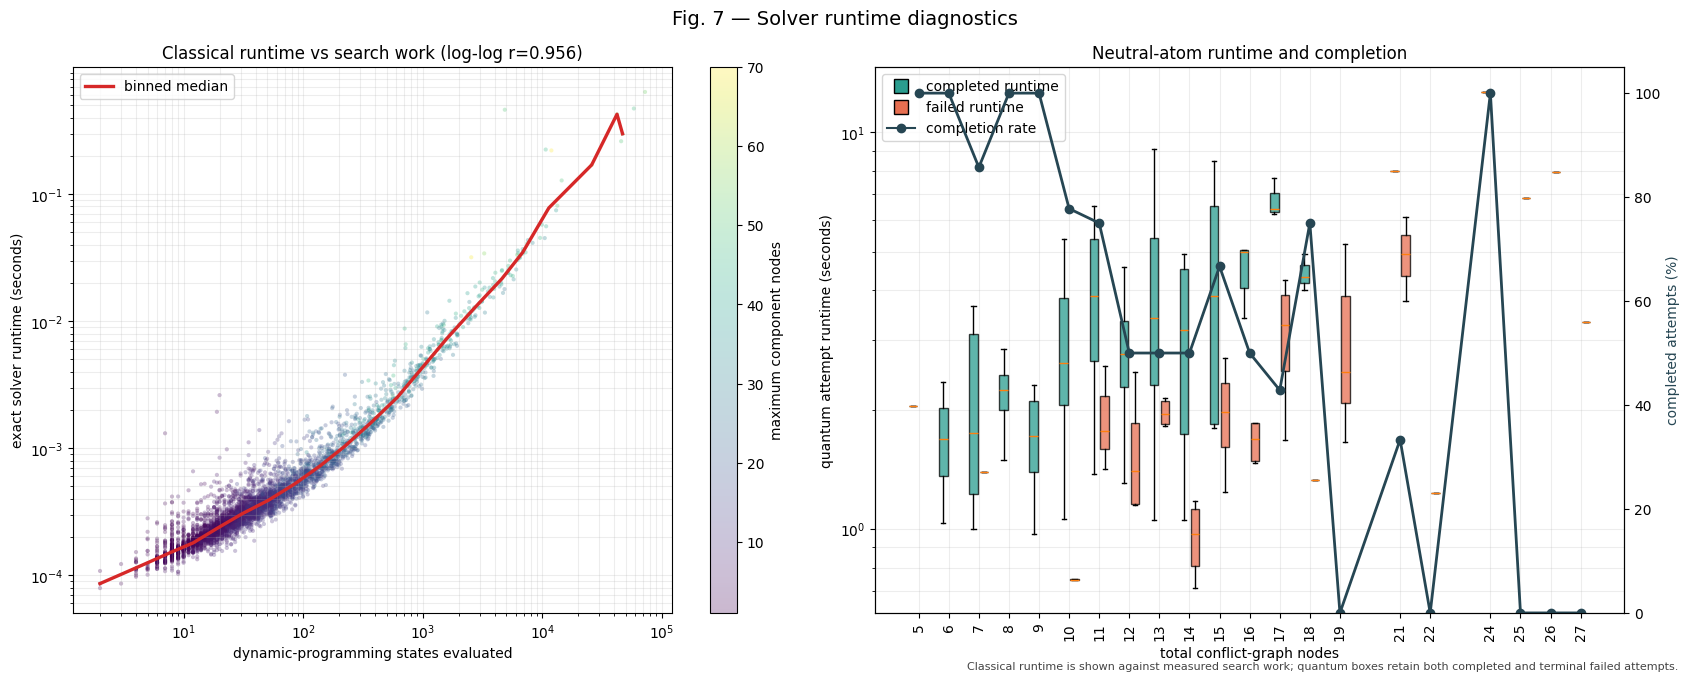

WindowsPath('C:/Projects/Summer School Challenge/Neutral-Atom-QC-for-MHT/outputs/figures/fig7_runtime_diagnostics.png')

In [12]:
# Fig. 7 — Relate runtime to actual classical search work and quantum outcomes.
figure, (classical_axis, quantum_axis) = plt.subplots(1, 2, figsize=(17, 6.8))
classical_runtime_rows = []
for row in benchmark_records:
    if row.get("exact_status") != "optimal" or row.get("exact_runtime_seconds") in (None, 0):
        continue
    diagnostics = json.loads(row.get("exact_diagnostics_json") or "{}")
    states_evaluated = diagnostics.get("states_evaluated")
    if states_evaluated is None or int(states_evaluated) < 1:
        continue
    classical_runtime_rows.append((
        int(states_evaluated), float(row["exact_runtime_seconds"]),
        int(row["maximum_component_nodes"]),
    ))
classical_states = np.asarray([item[0] for item in classical_runtime_rows], dtype=float)
classical_runtimes = np.asarray([item[1] for item in classical_runtime_rows], dtype=float)
classical_sizes = np.asarray([item[2] for item in classical_runtime_rows], dtype=float)
runtime_scatter = classical_axis.scatter(
    classical_states, classical_runtimes, c=classical_sizes, cmap="viridis",
    s=9, alpha=0.28, linewidths=0, rasterized=True,
)
if classical_states.size:
    state_bins = np.geomspace(classical_states.min(), classical_states.max(), 22)
    bin_centers, bin_medians = [], []
    for lower, upper in zip(state_bins[:-1], state_bins[1:], strict=True):
        selected = (classical_states >= lower) & (classical_states < upper)
        if np.any(selected):
            bin_centers.append(np.median(classical_states[selected]))
            bin_medians.append(np.median(classical_runtimes[selected]))
    classical_axis.plot(
        bin_centers, bin_medians, color="#D62828", linewidth=2.4,
        label="binned median",
    )
    log_correlation = np.corrcoef(
        np.log10(classical_states), np.log10(classical_runtimes)
    )[0, 1]
else:
    log_correlation = np.nan
classical_axis.set(
    xlabel="dynamic-programming states evaluated",
    ylabel="exact solver runtime (seconds)",
    title=f"Classical runtime vs search work (log-log r={log_correlation:.3f})",
)
classical_axis.set_xscale("log")
classical_axis.set_yscale("log")
classical_axis.grid(alpha=0.22, which="both")
classical_axis.legend(loc="upper left")
figure.colorbar(runtime_scatter, ax=classical_axis, label="maximum component nodes")

total_graph_nodes = sorted({
    int(row["graph_nodes"])
    for row in attempted_quantum_rows
})
successful_runtime_groups = []
failed_runtime_groups = []
failed_runtime_positions = []
completion_rates = []
for node_count in total_graph_nodes:
    attempts = [
        row for row in attempted_quantum_rows
        if int(row["graph_nodes"]) == node_count
    ]
    successful = finite_values(
        [row for row in attempts if row.get("quantum_status") == "completed"],
        "quantum_runtime_seconds",
    )
    failed = finite_values(
        [row for row in attempts if row.get("quantum_status") != "completed"],
        "quantum_runtime_seconds",
    )
    successful_runtime_groups.append(successful)
    if failed.size:
        failed_runtime_groups.append(failed)
        failed_runtime_positions.append(node_count + 0.18)
    completion_rates.append(100.0 * len(successful) / len(attempts))
successful_boxplot = quantum_axis.boxplot(
    successful_runtime_groups, positions=np.asarray(total_graph_nodes) - 0.18,
    widths=0.28, patch_artist=True, manage_ticks=False, showfliers=False,
)
for box in successful_boxplot["boxes"]:
    box.set(facecolor="#2A9D8F", alpha=0.75)
if failed_runtime_groups:
    failed_boxplot = quantum_axis.boxplot(
        failed_runtime_groups, positions=failed_runtime_positions,
        widths=0.28, patch_artist=True, manage_ticks=False, showfliers=False,
    )
    for box in failed_boxplot["boxes"]:
        box.set(facecolor="#E76F51", alpha=0.75)
quantum_axis.set(
    xlabel="total conflict-graph nodes",
    ylabel="quantum attempt runtime (seconds)",
    title="Neutral-atom runtime and completion",
)
quantum_axis.set_xticks(total_graph_nodes)
quantum_axis.tick_params(axis="x", labelrotation=90)
quantum_axis.set_yscale("log")
quantum_axis.grid(alpha=0.22, which="both")
completion_axis = quantum_axis.twinx()
completion_axis.plot(
    total_graph_nodes, completion_rates, color="#264653", marker="o", linewidth=2,
)
completion_axis.set_ylabel("completed attempts (%)", color="#264653")
completion_axis.set_ylim(0, 105)
quantum_axis.legend(
    handles=[
        Line2D([0], [0], marker="s", color="none", markerfacecolor="#2A9D8F", markersize=10, label="completed runtime"),
        Line2D([0], [0], marker="s", color="none", markerfacecolor="#E76F51", markersize=10, label="failed runtime"),
        Line2D([0], [0], color="#264653", marker="o", label="completion rate"),
    ],
    loc="upper left",
)
figure.suptitle("Fig. 7 — Solver runtime diagnostics", fontsize=14)
figure.text(
    0.99, 0.01,
    "Classical runtime is shown against measured search work; quantum boxes retain both "
    "completed and terminal failed attempts.",
    ha="right", fontsize=8, color="#444444",
)
fig7_path = finish_figure(figure, "fig7_runtime_diagnostics.png")
fig7_path

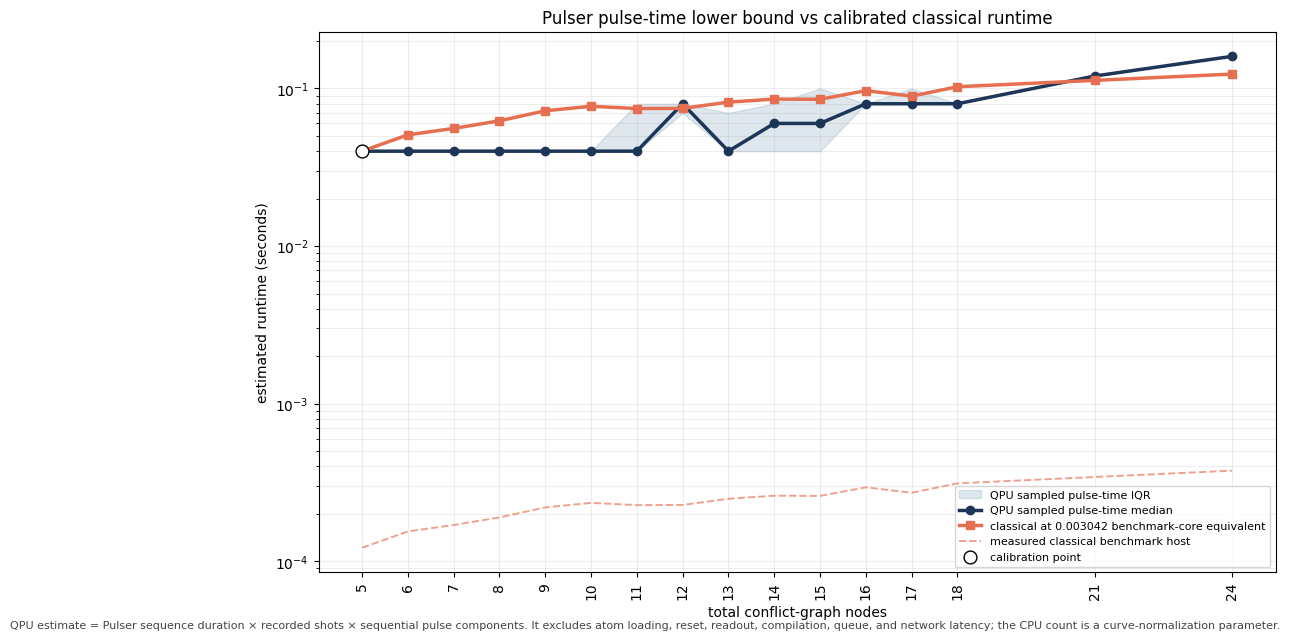

{'pulser_sequence_duration_ns': 40000,
 'pulse_seconds_per_component_shot': 4e-05,
 'recorded_shots_per_component': (1000,),
 'smallest_problem_nodes': 5,
 'smallest_qpu_sampled_pulse_seconds': np.float64(0.04),
 'smallest_qpu_single_shot_seconds': np.float64(4e-05),
 'smallest_measured_classical_seconds': np.float64(0.00012169999536126852),
 'reference_cpu_count_in_benchmark_core_equivalents': np.float64(0.003042499884031713),
 'single_shot_cpu_count_in_benchmark_core_equivalents': np.float64(3.0424998840317126),
 'figure': 'C:\\Projects\\Summer School Challenge\\Neutral-Atom-QC-for-MHT\\outputs\\figures\\fig8_hardware_runtime_comparison.png',
 'scope': 'pulse-time lower bound; hardware overheads excluded'}

In [13]:
# Fig. 8 — Compare a Pulser-derived QPU pulse-time lower bound with classical CPU time.
# Pulser reports sequence duration in ns. Each recorded bitstring sample would require
# a separate destructive QPU shot, so the solve estimate includes all recorded shots.
if example_run.program is None:
    raise RuntimeError("The validated Pulser program is unavailable")
pulser_sequence_duration_ns = int(
    example_run.program.sequence.get_duration(include_fall_time=True)
)
if pulser_sequence_duration_ns <= 0:
    raise RuntimeError("Pulser returned a non-positive sequence duration")

hardware_runtime_rows = []
recorded_shot_counts = set()
for row in benchmark_records:
    if (
        not bool(row.get("quantum_attempted"))
        or row.get("quantum_status") != "completed"
        or row.get("exact_status") != "optimal"
        or row.get("exact_runtime_seconds") in (None, 0)
    ):
        continue
    diagnostics = json.loads(row.get("quantum_diagnostics_json") or "{}")
    pulse_components = [
        component for component in diagnostics.get("components", ())
        if component.get("execution_mode") == "pulser_qutip"
    ]
    shot_counts = [
        int(component.get("sample_count", 0))
        for component in pulse_components
    ]
    if not shot_counts or any(shots < 1 for shots in shot_counts):
        continue
    recorded_shot_counts.update(shot_counts)
    hardware_runtime_rows.append({
        "node_count": int(row["graph_nodes"]),
        "classical_host_seconds": float(row["exact_runtime_seconds"]),
        "qpu_single_shot_seconds": (
            len(pulse_components) * pulser_sequence_duration_ns * 1e-9
        ),
        "qpu_sampled_seconds": (
            sum(shot_counts) * pulser_sequence_duration_ns * 1e-9
        ),
    })

if not hardware_runtime_rows:
    raise RuntimeError("No completed Pulser benchmark rows are available")
hardware_node_counts = sorted({
    row["node_count"] for row in hardware_runtime_rows
})
hardware_groups = {
    node_count: [
        row for row in hardware_runtime_rows
        if row["node_count"] == node_count
    ]
    for node_count in hardware_node_counts
}
def grouped_hardware_values(key):
    return [
        np.asarray([row[key] for row in hardware_groups[node_count]], dtype=float)
        for node_count in hardware_node_counts
    ]

qpu_sampled_groups = grouped_hardware_values("qpu_sampled_seconds")
qpu_single_shot_groups = grouped_hardware_values("qpu_single_shot_seconds")
classical_host_groups = grouped_hardware_values("classical_host_seconds")
qpu_sampled_medians = np.asarray([np.median(group) for group in qpu_sampled_groups])
qpu_single_shot_medians = np.asarray([
    np.median(group) for group in qpu_single_shot_groups
])
classical_host_medians = np.asarray([
    np.median(group) for group in classical_host_groups
])
qpu_lower_quartiles = np.asarray([
    np.percentile(group, 25) for group in qpu_sampled_groups
])
qpu_upper_quartiles = np.asarray([
    np.percentile(group, 75) for group in qpu_sampled_groups
])

# Under ideal inverse scaling, T(N CPUs) = T(1 CPU) / N. This calibrated
# effective CPU count makes the smallest classical and sampled-QPU medians equal.
reference_cpu_count = classical_host_medians[0] / qpu_sampled_medians[0]
single_shot_reference_cpu_count = (
    classical_host_medians[0] / qpu_single_shot_medians[0]
)
classical_reference_medians = classical_host_medians / reference_cpu_count

figure, runtime_axis = plt.subplots(figsize=(10.5, 6.4))
runtime_axis.fill_between(
    hardware_node_counts, qpu_lower_quartiles, qpu_upper_quartiles,
    color="#457B9D", alpha=0.18, label="QPU sampled pulse-time IQR",
)
runtime_axis.plot(
    hardware_node_counts, qpu_sampled_medians, color="#1D3557", marker="o",
    linewidth=2.5, label="QPU sampled pulse-time median",
)
runtime_axis.plot(
    hardware_node_counts, classical_reference_medians, color="#E76F51", marker="s",
    linewidth=2.5, label=(
        f"classical at {reference_cpu_count:.4g} benchmark-core equivalent"
    ),
)
runtime_axis.plot(
    hardware_node_counts, classical_host_medians, color="#E76F51", linestyle="--",
    linewidth=1.4, alpha=0.65, label="measured classical benchmark host",
)
runtime_axis.scatter(
    hardware_node_counts[0], qpu_sampled_medians[0], s=85, facecolors="white",
    edgecolors="black", zorder=5, label="calibration point",
)
runtime_axis.set(
    xlabel="total conflict-graph nodes",
    ylabel="estimated runtime (seconds)",
    title="Pulser pulse-time lower bound vs calibrated classical runtime",
)
runtime_axis.set_xticks(hardware_node_counts)
runtime_axis.tick_params(axis="x", labelrotation=90)
runtime_axis.set_yscale("log")
runtime_axis.grid(alpha=0.22, which="both")
runtime_axis.legend(loc="best", fontsize=8)
figure.text(
    0.99, 0.01,
    "QPU estimate = Pulser sequence duration × recorded shots × sequential pulse "
    "components. It excludes atom loading, reset, readout, compilation, queue, and "
    "network latency; the CPU count is a curve-normalization parameter.",
    ha="right", fontsize=8, color="#444444",
)
fig8_path = finish_figure(figure, "fig8_hardware_runtime_comparison.png")
hardware_runtime_summary = {
    "pulser_sequence_duration_ns": pulser_sequence_duration_ns,
    "pulse_seconds_per_component_shot": pulser_sequence_duration_ns * 1e-9,
    "recorded_shots_per_component": tuple(sorted(recorded_shot_counts)),
    "smallest_problem_nodes": hardware_node_counts[0],
    "smallest_qpu_sampled_pulse_seconds": qpu_sampled_medians[0],
    "smallest_qpu_single_shot_seconds": qpu_single_shot_medians[0],
    "smallest_measured_classical_seconds": classical_host_medians[0],
    "reference_cpu_count_in_benchmark_core_equivalents": reference_cpu_count,
    "single_shot_cpu_count_in_benchmark_core_equivalents": (
        single_shot_reference_cpu_count
    ),
    "figure": str(fig8_path),
    "scope": "pulse-time lower bound; hardware overheads excluded",
}
hardware_runtime_summary